Machine Learning Algorithms Development

In [1]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import catboost as catboost
import xgboost as xgb
import yaml
import os
import logging
from contextlib import nullcontext
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

mlflow_tracking_uri = 'http://localhost:5001'  # Optional: e.g., 'http://localhost:5555'

In [2]:
# Load dataset
data_path = '../data/processed/AB_NYC_2019_feature_engineered.csv'
data = pd.read_csv(data_path)
X = data.drop('log_price', axis=1)
y = data['log_price']
X.shape

(33832, 229)

In [ ]:
# Perform splits

# First split: keep test set sealed
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: create validation set from train_val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (21652, 229)
Validation shape: (5413, 229)
Test shape: (6767, 229)


In [4]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

# Keep original feature matrices before RFE filtering
X_train_full = X_train.copy()
X_val_full = X_val.copy()
X_test_full = X_test.copy()

# Use XGBoost for RFE
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Number of features to select
n_features_to_select = min(232, X_train_full.shape[1])

# RFE fitted only on training data
rfe_selector = RFE(
    estimator=xgb_model,
    n_features_to_select=n_features_to_select,
    step=1
)

rfe_selector.fit(X_train_full, y_train)

# Selected and ignored features
rfe_selected_features = X_train_full.columns[rfe_selector.support_]
rfe_ignored_features = X_train_full.columns[~rfe_selector.support_]

print("Selected Features by RFE:")
for feature in rfe_selected_features:
    print(f" - {feature}")

print("\nFeatures Ignored by RFE:")
for feature in rfe_ignored_features:
    print(f" - {feature}")

# Store for config
selected_features_dict = {
    "rfe": list(rfe_selected_features)
}

# Apply selected features to train, validation, and test sets
X_train = X_train_full[rfe_selected_features].copy()
X_val = X_val_full[rfe_selected_features].copy()
X_test = X_test_full[rfe_selected_features].copy()

print("X_train shape after RFE:", X_train.shape)
print("X_val shape after RFE:", X_val.shape)
print("X_test shape after RFE:", X_test.shape)

Selected Features by RFE:
 - neighbourhood_group
 - latitude
 - longitude
 - room_type
 - minimum_nights
 - number_of_reviews
 - reviews_per_month
 - calculated_host_listings_count
 - availability_365
 - has_reviews
 - log_total_reviews
 - dist_km_times_square
 - dist_km_wall_street
 - dist_km_central_park
 - neighbourhoods_Bronx_Baychester
 - neighbourhoods_Bronx_Belmont
 - neighbourhoods_Bronx_Bronxdale
 - neighbourhoods_Bronx_Castle Hill
 - neighbourhoods_Bronx_City Island
 - neighbourhoods_Bronx_Claremont Village
 - neighbourhoods_Bronx_Clason Point
 - neighbourhoods_Bronx_Co-op City
 - neighbourhoods_Bronx_Concourse
 - neighbourhoods_Bronx_Concourse Village
 - neighbourhoods_Bronx_East Morrisania
 - neighbourhoods_Bronx_Eastchester
 - neighbourhoods_Bronx_Edenwald
 - neighbourhoods_Bronx_Fieldston
 - neighbourhoods_Bronx_Fordham
 - neighbourhoods_Bronx_Highbridge
 - neighbourhoods_Bronx_Hunts Point
 - neighbourhoods_Bronx_Kingsbridge
 - neighbourhoods_Bronx_Longwood
 - neighbourho

In [5]:
# Optional MLflow setup
if mlflow_tracking_uri:
    mlflow.set_tracking_uri(mlflow_tracking_uri)
    mlflow.set_experiment("NYC_Airbnb_price_model")

In [6]:
# Define models and hyperparameter grids
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'Catboost': catboost.CatBoostRegressor(verbose=0)
}

model_grids = {
    'LinearRegression': {},
    'RandomForest': {
        'n_estimators': [100, 150],
        'max_depth': [None, 10, 20, 30]
    },
    'GradientBoosting': {
        'n_estimators': [100, 250],
        'learning_rate': [0.1, 0.05],
        'max_depth': [3, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'learning_rate': [0.1, 0.05],
        'max_depth': [3, 10, 20]
    },
    'Catboost': {
        'iterations': [100, 200],
        'learning_rate': [0.1, 0.05],
        'depth': [6, 10]
    }
}

In [7]:
def evaluate_model_with_gridsearch(name, model, grid, X_train, y_train, X_eval, y_eval):
    if grid:
        clf = GridSearchCV(
            estimator=model,
            param_grid=grid,
            cv=5,
            scoring="r2",
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
        best_cv_score = clf.best_score_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()
        best_cv_score = None

    y_pred = best_model.predict(X_eval)

    mae = mean_absolute_error(y_eval, y_pred)
    mse = mean_squared_error(y_eval, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, y_pred)

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "model": best_model,
        "params": best_params,
        "best_cv_score": best_cv_score,
        "y_pred": y_pred
    }

print("MLflow tracking URI:", mlflow_tracking_uri)

MLflow tracking URI: http://localhost:5001


In [8]:
results = {}

print("MLflow tracking URI:", mlflow_tracking_uri)

with mlflow.start_run(run_name="model_comparison_validation") if mlflow_tracking_uri else nullcontext():
    for name, model in models.items():
        logger.info(f"Training {name}...")

        with mlflow.start_run(run_name=name, nested=True) if mlflow_tracking_uri else nullcontext():
            evaluation = evaluate_model_with_gridsearch(
                name=name,
                model=model,
                grid=model_grids[name],
                X_train=X_train,
                y_train=y_train,
                X_eval=X_val,
                y_eval=y_val
            )

            results[name] = evaluation

            if mlflow_tracking_uri:
                mlflow.log_params(evaluation["params"])
                mlflow.log_metrics({
                    "val_mae": evaluation["mae"],
                    "val_mse": evaluation["mse"],
                    "val_rmse": evaluation["rmse"],
                    "val_r2": evaluation["r2"]
                })

                if evaluation["best_cv_score"] is not None:
                    mlflow.log_metric("best_cv_r2", evaluation["best_cv_score"])

                mlflow.sklearn.log_model(
                    evaluation["model"],
                    artifact_path=name.lower().replace(" ", "_")
                )

            print(
                f"{name} | "
                f"Validation R²: {evaluation['r2']:.4f}, "
                f"Validation RMSE: {evaluation['rmse']:.4f}, "
                f"Validation MAE: {evaluation['mae']:.4f}"
            )

MLflow tracking URI: http://localhost:5001


INFO:root:Training LinearRegression...
2026/05/14 09:23:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
INFO:root:Training RandomForest...


LinearRegression | Validation R²: 0.6592, Validation RMSE: 0.3072, Validation MAE: 0.2399
🏃 View run LinearRegression at: http://localhost:5001/#/experiments/2/runs/c618e4fc78c64a4495d15ffd619e3938
🧪 View experiment at: http://localhost:5001/#/experiments/2


2026/05/14 09:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
INFO:root:Training GradientBoosting...


RandomForest | Validation R²: 0.6984, Validation RMSE: 0.2890, Validation MAE: 0.2254
🏃 View run RandomForest at: http://localhost:5001/#/experiments/2/runs/0a506c7580a74cbaa574b7e5398d9bce
🧪 View experiment at: http://localhost:5001/#/experiments/2


...

GradientBoosting | Validation R²: 0.6951, Validation RMSE: 0.2906, Validation MAE: 0.2275
🏃 View run GradientBoosting at: http://localhost:5001/#/experiments/2/runs/2cd596115c2a48418499b782b24423c6
🧪 View experiment at: http://localhost:5001/#/experiments/2


2026/05/14 09:47:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
INFO:root:Training Catboost...


XGBoost | Validation R²: 0.6952, Validation RMSE: 0.2905, Validation MAE: 0.2242
🏃 View run XGBoost at: http://localhost:5001/#/experiments/2/runs/c16739cd18df44d6b25eafcf5dca8fe6
🧪 View experiment at: http://localhost:5001/#/experiments/2


2026/05/14 09:49:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Catboost | Validation R²: 0.7062, Validation RMSE: 0.2852, Validation MAE: 0.2221
🏃 View run Catboost at: http://localhost:5001/#/experiments/2/runs/b1ba89b0ae3c4e5c81d3cfc21bb570c6
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run model_comparison_validation at: http://localhost:5001/#/experiments/2/runs/a6fc9240073146438e4b5a775a48debb
🧪 View experiment at: http://localhost:5001/#/experiments/2


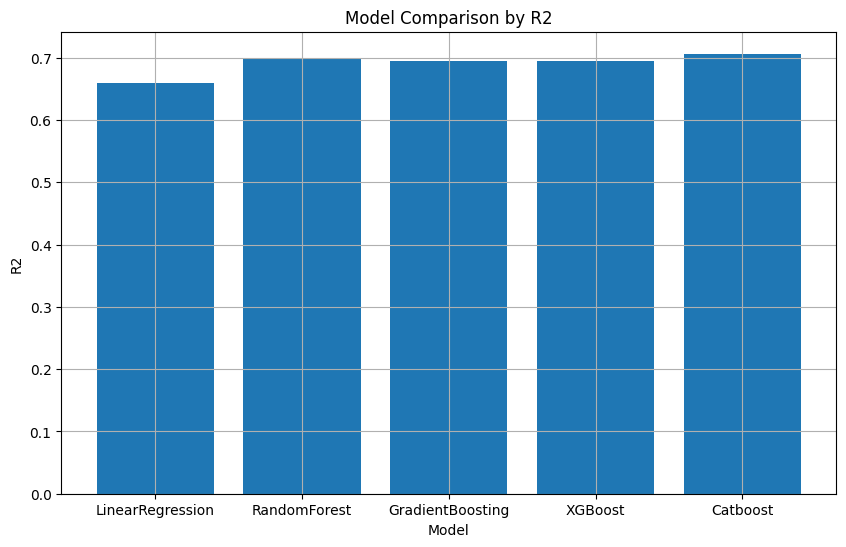

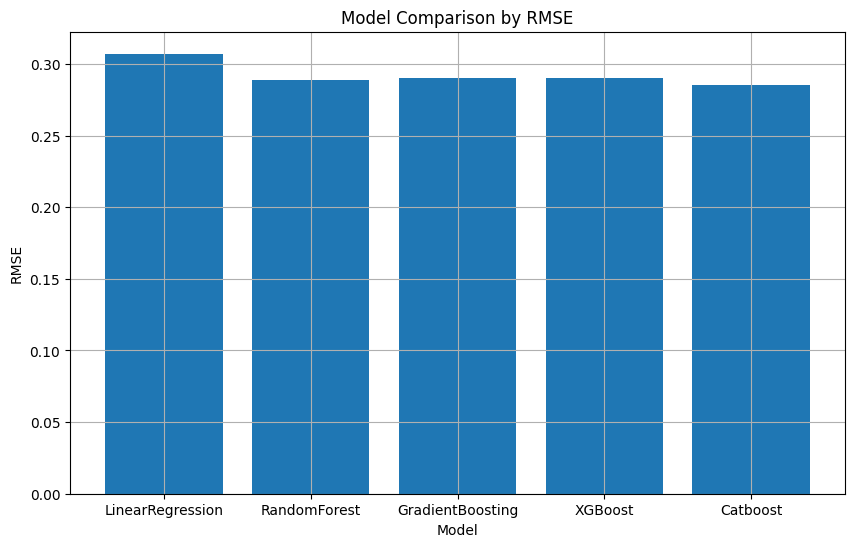

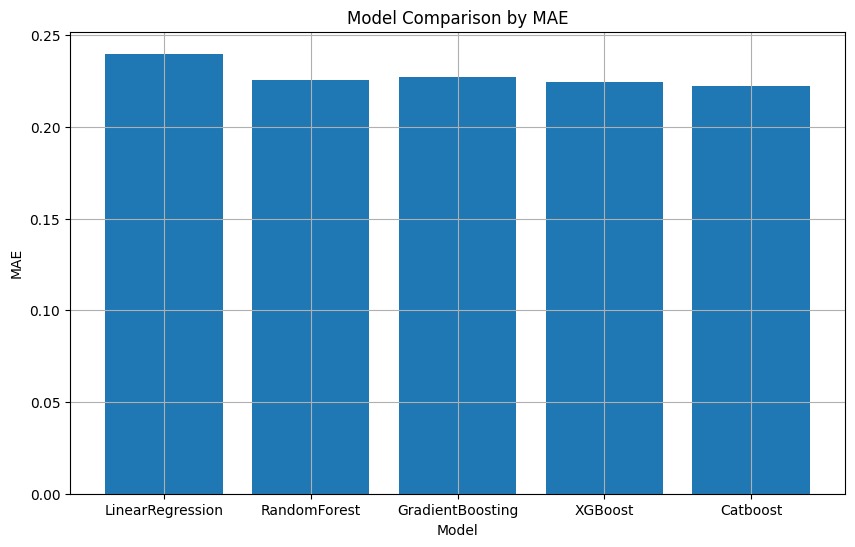

In [9]:
def plot_model_metrics(results, metric='r2'):
    names = list(results.keys())
    values = [results[name][metric] for name in names]

    plt.figure(figsize=(10, 6))
    plt.bar(names, values)
    plt.title(f'Model Comparison by {metric.upper()}')
    plt.xlabel('Model')
    plt.ylabel(metric.upper())
    plt.grid(True)
    plt.show()

# Example usage:
plot_model_metrics(results, metric='r2')
plot_model_metrics(results, metric='rmse')
plot_model_metrics(results, metric='mae')

Select best model using validation R²

In [10]:
# Display information about the best model on validation set
best_model_name = max(results, key=lambda x: results[x]["r2"])
best_validation_model = results[best_model_name]["model"]

print(f"🏆 Best validation model: {best_model_name}")
print(f"Validation R²: {results[best_model_name]['r2']:.4f}")
print(f"Validation MAE: {results[best_model_name]['mae']:.4f}")
print(f"Validation RMSE: {results[best_model_name]['rmse']:.4f}")
print(f"Validation MSE: {results[best_model_name]['mse']:.4f}")

🏆 Best validation model: Catboost
Validation R²: 0.7062
Validation MAE: 0.2221
Validation RMSE: 0.2852
Validation MSE: 0.0814


Final test evaluation

In [11]:
# Final prediction on sealed test set
y_test_pred = best_validation_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final Test Results - {best_model_name}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

Final Test Results - Catboost
Test R²: 0.7049
Test MAE: 0.2226
Test RMSE: 0.2853
Test MSE: 0.0814


In [12]:
# Convert log predictions back to price scale

y_test_price = np.expm1(y_test)
y_test_pred_price = np.expm1(y_test_pred)

test_mae_price = mean_absolute_error(y_test_price, y_test_pred_price)
test_mse_price = mean_squared_error(y_test_price, y_test_pred_price)
test_rmse_price = np.sqrt(test_mse_price)
test_r2_price = r2_score(y_test_price, y_test_pred_price)

print("Final Test Results in Price Scale")
print(f"Test R² Price Scale: {test_r2_price:.4f}")
print(f"Test MAE Price Scale: ${test_mae_price:.2f}")
print(f"Test RMSE Price Scale: ${test_rmse_price:.2f}")
print(f"Test MSE Price Scale: ${test_mse_price:.2f}")



Final Test Results in Price Scale
Test R² Price Scale: 0.6546
Test MAE Price Scale: $23.75
Test RMSE Price Scale: $32.79
Test MSE Price Scale: $1074.88


Segment-Level Evaluation

In [13]:
test_results = X_test.copy()

test_results["actual_log_price"] = y_test
test_results["predicted_log_price"] = y_test_pred

test_results["actual_price"] = np.expm1(y_test)
test_results["predicted_price"] = np.expm1(y_test_pred)

test_results["absolute_error_log"] = np.abs(
    test_results["actual_log_price"] - test_results["predicted_log_price"]
)

test_results["absolute_error_price"] = np.abs(
    test_results["actual_price"] - test_results["predicted_price"]
)

test_results["squared_error_log"] = (
    test_results["actual_log_price"] - test_results["predicted_log_price"]) ** 2

In [14]:
def segment_level_evaluation(df_results, segment_col):
    segment_eval = (
        df_results
        .groupby(segment_col)
        .agg(
            n_observations=("actual_log_price", "count"),
            mean_actual_price=("actual_price", "mean"),
            mean_predicted_price=("predicted_price", "mean"),
            mae_log=("absolute_error_log", "mean"),
            rmse_log=("squared_error_log", lambda x: np.sqrt(np.mean(x))),
            mae_price=("absolute_error_price", "mean"),
            median_abs_error_price=("absolute_error_price", "median")
        )
        .reset_index()
        .sort_values("mae_price", ascending=False)
    )

    return segment_eval

In [15]:
test_results["residual_price"] = test_results["actual_price"] - test_results["predicted_price"]

room_type_bias = (
    test_results
    .groupby("room_type")
    .agg(
            n_observations=("actual_log_price", "count"),
            mean_actual_price=("actual_price", "mean"),
            mean_predicted_price=("predicted_price", "mean"),
            mean_residual=("residual_price", "mean"),
            mae_log=("absolute_error_log", "mean"),
            rmse_log=("squared_error_log", lambda x: np.sqrt(np.mean(x))),
            mae_price=("absolute_error_price", "mean"),
            median_abs_error_price=("absolute_error_price", "median")
    
    )
    .sort_values("mean_residual", ascending=False)
)

room_type_bias["bias_pct_of_mean_price"] = (
    room_type_bias["mean_residual"] /
    room_type_bias["mean_actual_price"]
) * 100

room_type_bias

,n_observations,mean_actual_price,mean_predicted_price,mean_residual,mae_log,rmse_log,mae_price,median_abs_error_price,bias_pct_of_mean_price
room_type,,,,,,,,,
0.0,3365,147.040416,141.040883,5.999534,0.236571,0.300797,33.301428,27.286717,4.080194
1.0,3236,69.796354,67.426014,2.370339,0.206434,0.263528,14.308716,10.980748,3.396079
2.0,166,51.072289,49.178539,1.893750,0.254186,0.361589,14.023662,8.800629,3.707980


In [16]:
neighbourhood_group_bias = (
    test_results
    .groupby("neighbourhood_group")
    .agg(
            n_observations=("actual_log_price", "count"),
            mean_actual_price=("actual_price", "mean"),
            mean_predicted_price=("predicted_price", "mean"),
            mean_residual=("residual_price", "mean"),
            mae_log=("absolute_error_log", "mean"),
            rmse_log=("squared_error_log", lambda x: np.sqrt(np.mean(x))),
            mae_price=("absolute_error_price", "mean"),
            median_abs_error_price=("absolute_error_price", "median")
    
    )
    .sort_values("mean_residual", ascending=False)
)

neighbourhood_group_bias["bias_pct_of_mean_price"] = (
    neighbourhood_group_bias["mean_residual"] /
    neighbourhood_group_bias["mean_actual_price"]
) * 100

neighbourhood_group_bias


,n_observations,mean_actual_price,mean_predicted_price,mean_residual,mae_log,rmse_log,mae_price,median_abs_error_price,bias_pct_of_mean_price
neighbourhood_group,,,,,,,,,
2.0,2776,129.147334,124.159375,4.987959,0.222768,0.288188,27.622751,20.795784,3.862224
4.0,61,80.049180,76.112565,3.936615,0.247844,0.338889,21.823816,13.885899,4.917745
1.0,2922,97.990760,94.262159,3.728600,0.223187,0.284453,22.108447,15.272138,3.805053
3.0,853,80.438453,77.163783,3.274669,0.217889,0.275788,18.305702,12.902940,4.071025
0.0,155,69.619355,67.050064,2.569291,0.224157,0.278568,15.887636,11.630955,3.690484


In [17]:
test_results["price_range"] = pd.qcut(
    test_results["actual_price"],
    q=4,
    labels=["low_price", "mid_low_price", "mid_high_price", "high_price"]
)

segment_price_range = segment_level_evaluation(
    test_results,
    "price_range"
)

segment_price_range

C:\Users\Mestr\AppData\Local\Temp\ipykernel_6772\3916445893.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(segment_col)


,price_range,n_observations,mean_actual_price,mean_predicted_price,mae_log,rmse_log,mae_price,median_abs_error_price
3,high_price,1670,188.902994,152.456806,0.241811,0.301799,40.625427,34.596644
2,mid_high_price,1648,117.939927,122.529300,0.195515,0.243343,23.244045,20.742659
1,mid_low_price,1748,78.447368,82.239776,0.220370,0.272567,18.540322,14.679721
0,low_price,1701,48.307466,59.183132,0.232238,0.317374,13.010645,9.069980


In [18]:
# Save updated model config

best_params = results[best_model_name]["params"]

model_config = {
    "model": {
        "name": "NYC_Airbnb_log_price_model",
        "best_model": best_model_name,
        "parameters": best_params,
        "target_variable": "log_price",
        "validation_metrics": {
            "r2": float(results[best_model_name]["r2"]),
            "mae": float(results[best_model_name]["mae"]),
            "rmse": float(results[best_model_name]["rmse"]),
            "mse": float(results[best_model_name]["mse"])
        },
        "test_metrics_log_scale": {
            "r2": float(test_r2),
            "mae": float(test_mae),
            "rmse": float(test_rmse),
            "mse": float(test_mse)
        },

        "feature_sets": selected_features_dict
    }
}

config_path = "../configs/model_config.yaml"
os.makedirs(os.path.dirname(config_path), exist_ok=True)

with open(config_path, "w") as f:
    yaml.dump(model_config, f)

print(f"Saved model config to {config_path}")

Saved model config to ../configs/model_config.yaml
